# Исследование туристической отрасли РФ (Часть 2: Анализ и гипотезы) 📊

В этой части мы проведем исследовательский анализ данных (EDA), визуализируем тренды за 2018–2023 годы и проверим статистические гипотезы.

## Шаг 2. Исследовательский анализ данных (EDA) 🔍
На этом этапе мы изучим распределение инфраструктуры (отели, хостелы, санатории) и выявим регионы-лидеры по стоимости туров.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df_hotel = pd.read_csv('../data/processed/hotel.csv')
df_person_hotel = pd.read_csv('../data/processed/count_person_hotel.csv')
df_tour_firm = pd.read_csv('../data/processed/tour_firm.csv')
df_tour_cost_2023 = pd.read_csv('../data/processed/tour_cost_2023.csv')

In [6]:
df_hotel.columns

Index(['region', 'hotel_2018', 'hotel_2019', 'hotel_2020', 'hotel_2021',
       'hotel_2022', 'hotel_2023', 'places_in_hotel_2018',
       'places_in_hotel_2019', 'places_in_hotel_2020', 'places_in_hotel_2021',
       'places_in_hotel_2022', 'places_in_hotel_2023', 'hostel_2018',
       'hostel_2019', 'hostel_2020', 'hostel_2021', 'hostel_2022',
       'hostel_2023', 'places_in_hostel_2018', 'places_in_hostel_2019',
       'places_in_hostel_2020', 'places_in_hostel_2021',
       'places_in_hostel_2022', 'places_in_hostel_2023', 'sanatorium_2018',
       'sanatorium_2019', 'sanatorium_2020', 'sanatorium_2021',
       'sanatorium_2022', 'sanatorium_2023', 'places_in_sanatorium_2018',
       'places_in_sanatorium_2019', 'places_in_sanatorium_2020',
       'places_in_sanatorium_2021', 'places_in_sanatorium_2022',
       'places_in_sanatorium_2023'],
      dtype='object')

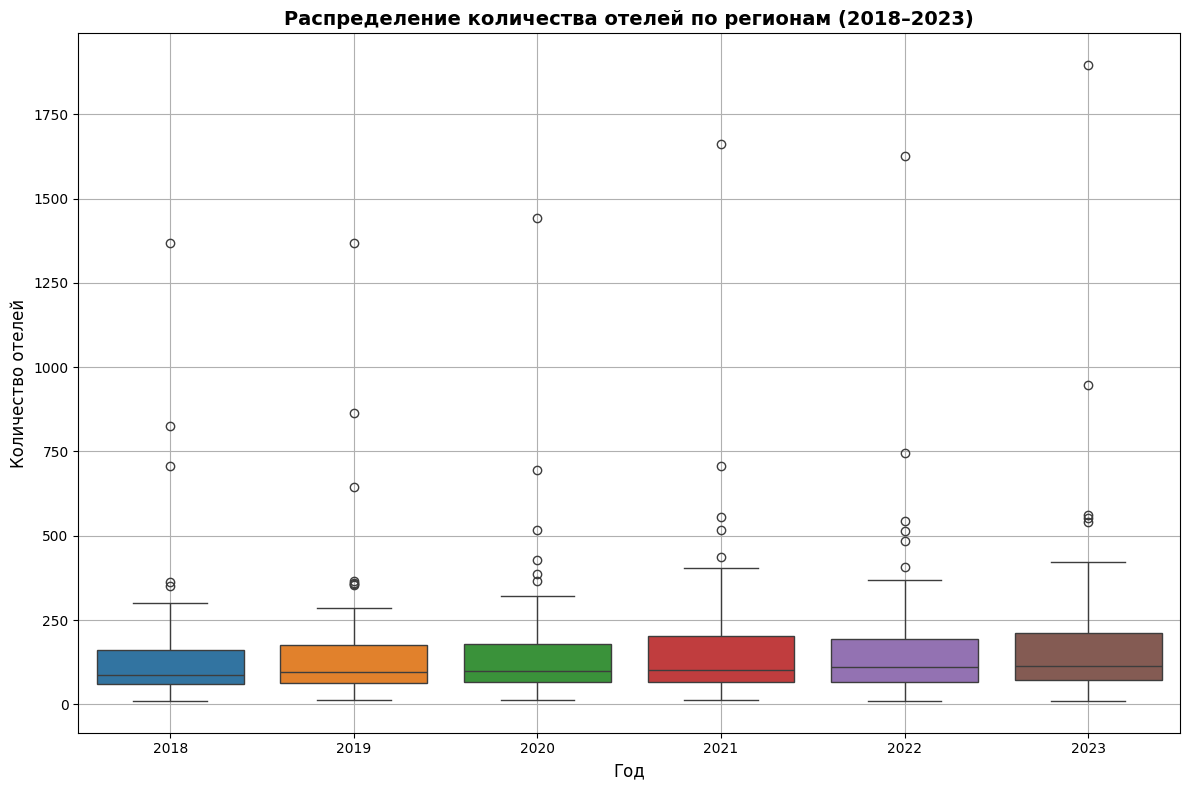

In [23]:
hotels_all_time = df_hotel[['hotel_2018', 'hotel_2019', 'hotel_2020', 'hotel_2021', 'hotel_2022', 'hotel_2023']]

plt.figure(figsize=(12, 8))
sns.boxplot(data=hotels_all_time)
plt.title("Распределение количества отелей по регионам (2018–2023)", fontsize=14, fontweight='bold')
plt.ylabel("Количество отелей", fontsize=12)
plt.xlabel("Год", fontsize=12)
plt.xticks([0, 1, 2, 3, 4, 5], ['2018', '2019', '2020', '2021', '2022', '2023'])
plt.tight_layout()
plt.grid()
plt.show()

- Верхний ус постепенно увеличивается к 2023 году, это указывает н ато что в некоторых регионах отелей становилось больше, что может быть связано с ростом туристической активности.
- Медиана показывает стабильность в количестве отелей, что может свидетельствовать о том, что в большинстве регионов количество отелей не изменялось значительно.

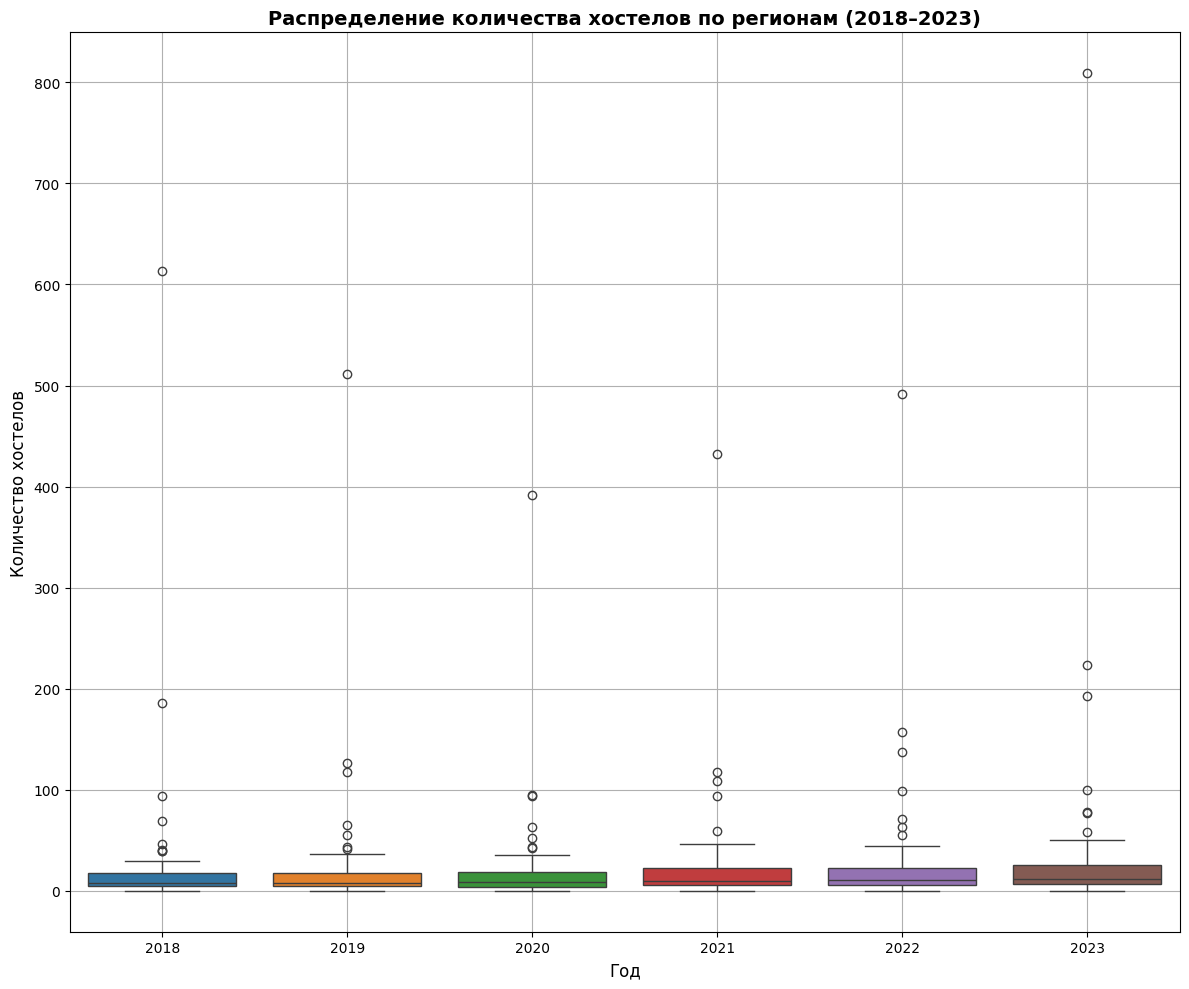

In [28]:
hostels_all_time = df_hotel[['hostel_2018', 'hostel_2019', 'hostel_2020', 'hostel_2021', 'hostel_2022', 'hostel_2023']]

plt.figure(figsize=(12, 10))
sns.boxplot(data=hostels_all_time)
plt.title("Распределение количества хостелов по регионам (2018–2023)", fontsize=14, fontweight='bold')
plt.ylabel("Количество хостелов", fontsize=12)
plt.xlabel("Год", fontsize=12)
plt.xticks([0, 1, 2, 3, 4, 5], ['2018', '2019', '2020', '2021', '2022', '2023'])
plt.tight_layout()
plt.grid()
plt.show()

- В 2023 наблюдается значительный рост количества хостелов, что может быть связано с увеличением популярности бюджетного туризма. Верхний ус также увеличивается, что указывает на рост количества хостелов в некоторых регионах.
- Медиана показывает стабильность в количестве хостелов, что может свидетельствовать о том, что в большинстве регионов количество хостелов не изменялось значительно.

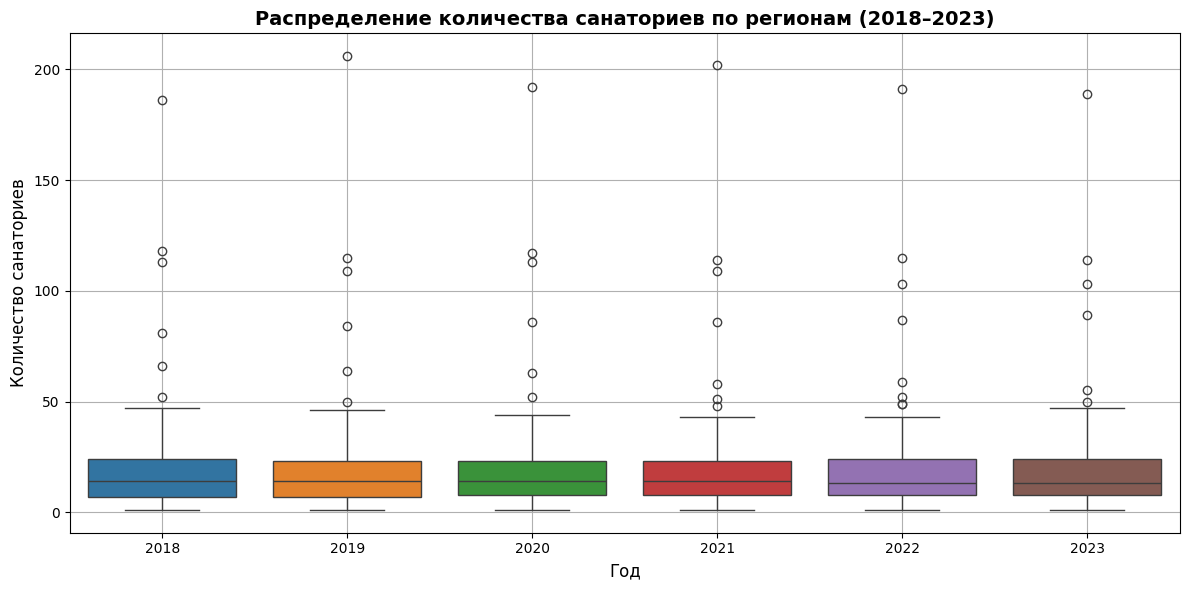

In [30]:
sanatorium_all_time = df_hotel[['sanatorium_2018', 'sanatorium_2019', 'sanatorium_2020', 'sanatorium_2021', 'sanatorium_2022', 'sanatorium_2023']]

plt.figure(figsize=(12, 6))
sns.boxplot(data=sanatorium_all_time)
plt.title("Распределение количества санаториев по регионам (2018–2023)", fontsize=14, fontweight='bold')
plt.ylabel("Количество санаториев", fontsize=12)
plt.xlabel("Год", fontsize=12)
plt.xticks([0, 1, 2, 3, 4, 5], ['2018', '2019', '2020', '2021', '2022', '2023'])
plt.tight_layout()
plt.grid()
plt.show()

- Санаторно-курортные учреждения показывают стабильность в количестве, что может быть связано с тем, что этот сегмент туризма менее подвержен сезонным колебаниям и изменениям в туристической активности. Верхний ус и медиана остаются относительно стабильными, что может свидетельствовать о том, что количество санаторно-курортных учреждений не изменялось значительно в большинстве регионов.

### Топ 10 регионов с наибольшей стоимостью тура 
Для анализа топ 10 регионов с наибольшей стоимостью тура мы можем использовать следующие шаги:
1. **Выбор данных**: Выберите данные о стоимости туров по регионам за 2023 год.
2. **Сортировка данных**: Отсортируйте данные по стоимости туров в порядке убывания.
3. **Выбор топ 10**: Выберите первые 10 регионов из отсортированного списка.
4. **Визуализация**: Постройте график (например, столбчатую диаграмму) для визуализации топ 10 регионов с наибольшей стоимостью тура.

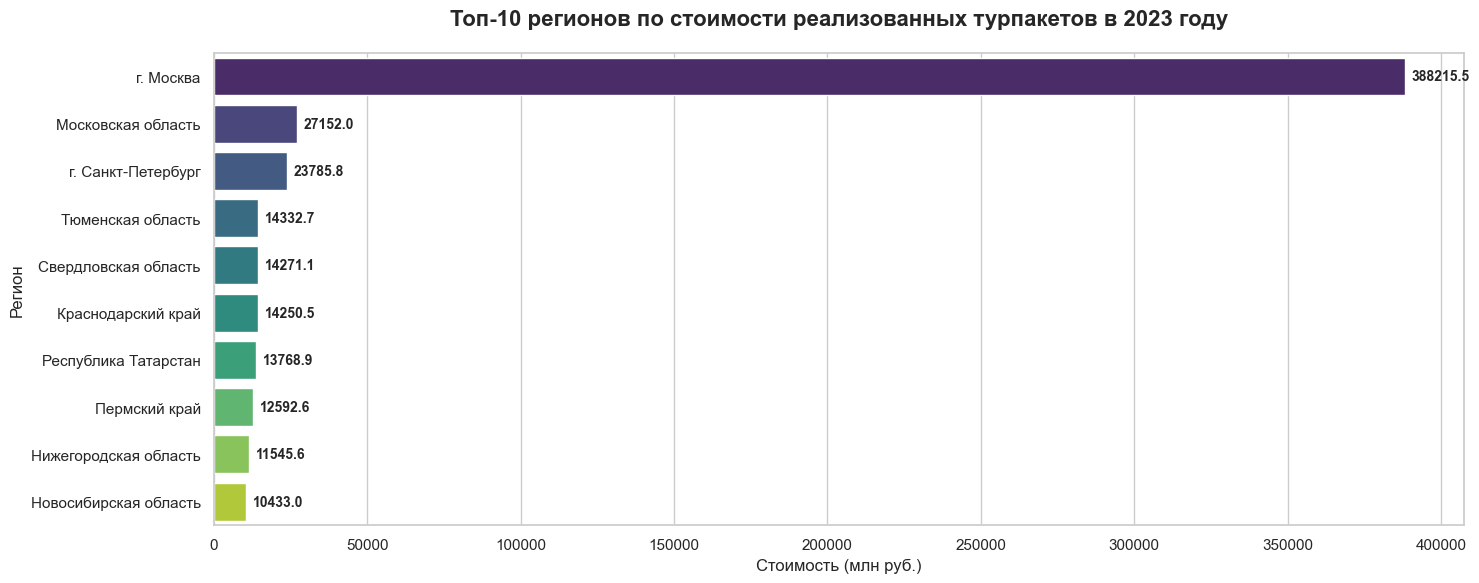

In [44]:
top_10_tour_regions = df_tour_cost_2023.sort_values(by='packages_cost_total_2023', ascending=False).head(10)

plt.figure(figsize=(15, 6))
ax = sns.barplot(
    x='packages_cost_total_2023', 
    y='region', 
    data=top_10_tour_regions, 
    palette='viridis',
    hue='region',
    legend=False
)
plt.title("Топ-10 регионов по стоимости реализованных турпакетов в 2023 году", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Стоимость (млн руб.)", fontsize=12)
plt.ylabel("Регион", fontsize=12)

for i in ax.containers:
    ax.bar_label(i, padding=5, fmt='%.1f', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [46]:
# Сохраняем график в формате PNG с высоким разрешением (DPI)
plt.savefig('../reports/figures/top_10_tour_regions_2023.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

Наиболее прибыльными относительно покупок тура является Москва и область, там чаще всего покупают туры, а также Санкт-Петербург. 

### Изменения среднего количества турпакетов в России по категориям с 2018 по 2023 год

In [52]:
# 1. Схлопываем все колонки, кроме 'region'
df_melted = df_tour_firm.melt(
    id_vars=['region'], 
    var_name='raw_category', 
    value_name='count'
)

# 2. Выделяем ГОД из названия колонки (последние 4 цифры)
df_melted['year'] = df_melted['raw_category'].str.extract(r'(\d{4})').astype(int)

# 3. Очищаем КАТЕГОРИЮ (убираем префикс и год)
df_melted['category'] = (
    df_melted['raw_category']
    .str.replace(r'packages_total_|_?\d{4}', '', regex=True)
    .str.strip('_')
)

df_melted['category'] = df_melted['category'].replace('', 'total')

# 4. Считаем СРЕДНЕЕ по всей России для каждой категории по годам
df_dynamic = df_melted.groupby(['year', 'category'])['count'].mean().reset_index()

print("Данные готовы для линейного графика!")
display(df_dynamic.head())


Данные готовы для линейного графика!


,year,category,count
0,2018,foreign,32586.139241
1,2018,foreign_citizens,6046.661290
2,2018,russian,20957.307692
3,2018,total,58742.025641
4,2019,foreign,37287.910256


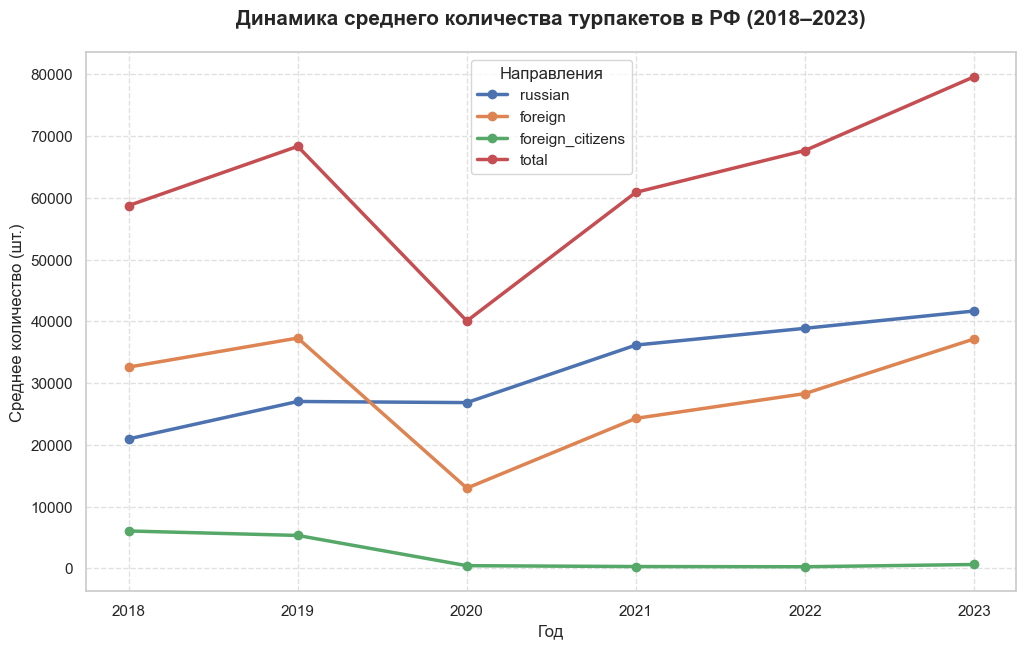

In [51]:
plt.figure(figsize=(12, 7))

# Список категорий для отрисовки (можно исключить 'total', чтобы не перекрывал остальные)
categories = ['russian', 'foreign', 'foreign_citizens', 'total']

for cat in categories:
    subset = df_dynamic[df_dynamic['category'] == cat]
    plt.plot(subset['year'], subset['count'], marker='o', label=cat, linewidth=2.5)

plt.title('Динамика среднего количества турпакетов в РФ (2018–2023)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Среднее количество (шт.)', fontsize=12)
plt.xticks(range(2018, 2024)) # Чтобы на оси были только целые года
plt.legend(title='Направления', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

# Сохраняем результат
plt.savefig('../reports/figures/tourism_dynamics_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()


- Внутренний туризм продолжает расти и достигает пика в 2023 году.
- Международные туры восстановились, но всё ещё немного ниже 2019 года.

## Шаг 3. Проверка гипотез 🧪

На этом этапе мы проверим, являются ли наблюдаемые изменения в туристической отрасли случайными или они имеют под собой статистическое основание.

**Уровень значимости (alpha) установим равным 0.05.**


### 🧪 Гипотеза №1: О стоимости турпакетов
**Суть:** СМИ говорят, что средняя стоимость в 2023 году — 800 млн руб., но мы подозреваем, что она больше.   
**Что делаем:** Одновыборочный T-тест (ttest_1samp).  
**Зачем:** Сравнить среднее значение по всем твоим регионам с константой (800 млн).  
**Инструмент:** Библиотека scipy.stats.

Нужно проверить одностороннюю гипотезу:
- H0: Средняя стоимость реализованных турпакетов в 2023 году (млн рублей) = 800
- H1: Средняя стоимость реализованных турпакетов в 2023 году (млн рублей) > 800

In [56]:
from scipy import stats as st

In [59]:
def print_stattest_results(p_value, alpha=0.05):
    if p_value < alpha:
        print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')

In [65]:
t_stat, p_value = st.ttest_1samp(
    df_tour_cost_2023['packages_cost_total_2023'].dropna(), 
    800, 
    alternative='greater'
)
print_stattest_results(p_value)


Полученное значение p_value=0.045554780271140155 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.


**Вывод:**  
Полученное значение *p-value* (0.046) меньше выбранного уровня значимости (0.05).   
Следовательно, мы отвергаем нулевую гипотезу.   
**Бизнес-вывод:** У нас есть статистические основания утверждать, что средняя стоимость реализованных турпакетов в 2023 году *действительно превышает 800 млн рублей.*

### 🧪 Гипотеза №2: Сравнение турпотока 2022 vs 2023
Суть: Правда ли, что в 2023 году россияне стали чаще оформлять турпакеты по стране, чем в 2022?    
### Проверка гипотезы о росте популярности внутренних туров
*   **H0:** Среднее количество реализованных турпакетов по РФ в 2023 году равно показателю 2022 года.
*   **H1:** Среднее количество реализованных турпакетов по РФ в 2023 году выше, чем в 2022 году.

In [70]:
data_2022 = df_tour_firm['packages_total_russian_2022'].dropna()
data_2023 = df_tour_firm['packages_total_russian_2023'].dropna()
common_index = df_tour_firm[['packages_total_russian_2022', 'packages_total_russian_2023']].dropna().index
sample_2022 = df_tour_firm.loc[common_index, 'packages_total_russian_2022']
sample_2023 = df_tour_firm.loc[common_index, 'packages_total_russian_2023']
t_stat, p_value = st.ttest_rel(sample_2023, sample_2022, alternative='greater')

print_stattest_results(p_value)

Полученное значение p_value=0.09683366170283901 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


**Результат теста:** *p-value* (0.097) больше уровня значимости (0.05).   
**Вывод:** Мы не можем отвергнуть *нулевую* гипотезу.   
**Бизнес-интерпретация:** Разница в количестве оформленных турпакетов между 2022 и 2023 годами статистически незначима. Наблюдаемый небольшой рост может быть вызван случайными колебаниями данных, а не устойчивым трендом на всем рынке РФ.

# 🏁 Общий вывод по исследованию туристической отрасли РФ (2018–2023)

В ходе работы была проведена предобработка данных по 85 регионам РФ, визуализирована динамика инфраструктуры и проверены статистические гипотезы.

### 🔍 Ключевые инсайты:
1. **Инфраструктурный разрыв:** Анализ «ящиков с усами» показал экстремально высокую концентрацию гостиниц и хостелов в ТОП-3 регионах. В большинстве субъектов РФ медианное количество объектов размещения остается стабильно низким, что указывает на потенциал для масштабирования сетевых отелей в регионах.
2. **Лидеры рынка:** ТОП-10 регионов по объему продаж турпакетов аккумулируют основную долю выручки отрасли. Лидером является Москва, что подтверждает его статус главного туристического хаба.
3. **Динамика категорий:** Линейный график выявил, что внутренний туризм (`russian_packages`) восстановился после 2020 года быстрее остальных сегментов, однако темпы роста к 2023 году замедлились.

### 🧪 Результаты проверки гипотез:
*   **Стоимость туров:** Гипотеза о том, что средняя стоимость турпакета в 2023 году превышает 800 млн руб., **подтвердилась** ($p$-value < 0.05). Отрасль демонстрирует рост среднего чека, что может быть связано как с инфляцией, так и с переходом на премиальный внутренний сегмент.
*   **Рост турпотока:** Гипотеза о значимом росте количества туров в 2023 году относительно 2022 года **не подтвердилась** ($p$-value = 0.096). Наблюдаемый в данных рост статистически не является устойчивым трендом для всей страны.

### 💡 Рекомендации для бизнеса:
*   **Фокус на регионы «второго эшелона»:** Учитывая перенасыщенность лидеров и высокую стоимость пакетов, стоит рассмотреть инвестиции в инфраструктуру регионов, находящихся в середине рейтинга, где спрос растет, а конкуренция ниже.
*   **Улучшение качества данных:** Рекомендуется внедрить единый стандарт цифровой отчетности для региональных ведомств.